In [3]:
from collections import defaultdict
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol, MakeScaffoldGeneric
from typing import Tuple, List, Any
from rdkit.DataStructs import BulkTanimotoSimilarity
from pathlib import Path
import pickle
from rdkit.Chem import MolFromSmiles, AllChem, MolToSmiles
import matplotlib.pyplot as plt
import numpy as np

from notebooks.utils.training_results import TrainingResults
from tqdm.auto import tqdm

model_names = ['rgfn_is_decomposable', 'rgfn_cost_biasing', 'rgfn_expl_bias']
template_name = 'synflow_64'

results_dict = defaultdict(list)
for model_name in tqdm(model_names):
    results_list = []
    for seed in range(3):
        result = TrainingResults(
            model_name=model_name,
            templates_name=template_name,
            seed=seed,
            task_name='seh',
            threshold=8.0,
            results_dir=Path('../results'),
        )
        result.load_heavy_stuff()
        results_list.append(result)
    results_dict[model_name] = results_list

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

{'SCENT (w/o C)': {'mean': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

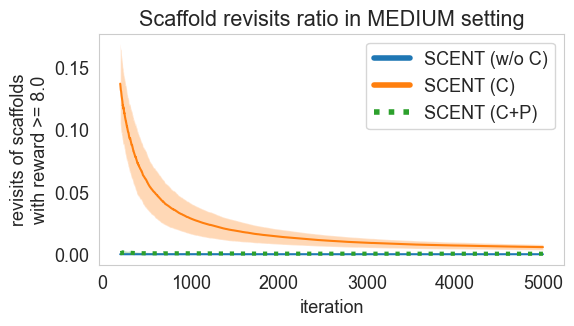

In [4]:

import json

plot_dict = {}
def plot_revisits_scaffolds(results_list: List[TrainingResults], reward_threshold: float, max_or_std='max', n: int = 64, mean: bool = False, start_at: int = 0, end_at: int = None):
    model_name = name_map[results_list[0].model_name]
    
    y_list_list = []
    for result in results_list:
        y_list = []
        scaffold_counter = {}
        for i, (scaffold, reward) in enumerate(zip(result.scaffolds, result.rewards)):
            if scaffold in scaffold_counter:
                scaffold_counter[scaffold] += 1
            elif reward >= reward_threshold:
                scaffold_counter[scaffold] = 0
            if i % n == 0:
                sum_counts = sum(scaffold_counter.values())
                if mean:
                    y_list.append(sum_counts / max(len(scaffold_counter), 1))
                else:
                    y_list.append(sum_counts)
        y_list_list.append(y_list)
    
    if end_at is None:
        end_at = len(y_list_list[0])
    x = np.array(range(len(y_list_list[0])))[start_at:end_at]
    y = np.array(y_list_list)[:, start_at:end_at]
    y_mean = np.mean(y, axis=0)
    y_std = np.std(y, axis=0)
    plot_dict[model_name] = {'mean': list(y_mean), 'std': list(y_std)}
    if 'C+P' in model_name:
        plt.plot(x, y_mean, label=model_name, linestyle=':', linewidth=3)
    else:
        plt.plot(x, y_mean, label=model_name)

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    else:
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
plt.figure(figsize=(6, 3))
plt.subplot(1, 1, 1)
# reward = 7.0
# for model_name, results_list in tqdm(results_dict.items()):
#     plot_revisits_scaffolds(results_list, reward_threshold=reward, max_or_std='std', mean=True, start_at=200, end_at=None)
# plt.title(f'Scaffold with sEH proxy >= {reward} in MEDIUM setting')
# plt.xlabel('iteration')
# plt.ylabel(f'average number of revisits of scaffolds with reward >= {reward}')
# plt.legend()

# plt.subplot(1, 2, 2)
name_map = {
    'rgfn_is_decomposable': 'SCENT (w/o C)',
    'rgfn_cost_biasing': 'SCENT (C)',
    'rgfn_expl_bias': 'SCENT (C+P)'
}
reward = 8.0
for model_name, results_list in tqdm(results_dict.items()):
    plot_revisits_scaffolds(results_list, reward_threshold=reward, max_or_std='std', mean=True, start_at=200, end_at=None)
plt.title(f'Scaffold revisits ratio in MEDIUM setting')
plt.xlabel('iteration')
plt.ylabel(f'revisits of scaffolds\nwith reward >= {reward}')
leg = plt.legend()
for line in leg.get_lines():
    line.set_linewidth(4.0)
plt.grid(False)
plt.savefig('outputs/scaffold_revisits.pdf', bbox_inches = 'tight')
print(plot_dict)
json.dump(plot_dict, open('plotting_data/figure_5.json', 'w'), indent=4)
plt.show()

In [5]:
# def plot_scaffold_exploitation(results_list: List[TrainingResults], threshold_list, max_or_std='max'):
#     repeated_list_list = []
#     model_name = results_list[0].model_name
#     for result in results_list:
#         repeats_list = []
#         for low in threshold_list:
#             scaffolds = [scaffold for scaffold, count in result.scaffold_max_score.items() if low <= count ]
#             counts = [result.scaffold_count[scaffold] for scaffold in scaffolds]
#             n_repeated = np.sum(counts) - len(counts)
#             average_repeat = n_repeated / len(counts)
#             repeats_list.append(average_repeat)
#         repeated_list_list.append(repeats_list)
#     
#     x = np.array(threshold_list)
#     y = np.array(repeated_list_list)
#     y_mean = np.mean(y, axis=0)
#     plt.plot(x, y_mean, label=model_name)
# 
#     if max_or_std == 'std':
#         y_std = np.std(y, axis=0)
#         _floor = y_mean - y_std
#         _floor[_floor < 0] = 0
#         plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
#     else:
#         y_min = np.min(y, axis=0)
#         y_max = np.max(y, axis=0)
#         plt.fill_between(x, y_min, y_max, alpha=0.3)
# 
# threshold_list = [5.0, 6.0, 7.0, 8.0]
# for model_name, results_list in tqdm(results_dict.items()):
#     plot_scaffold_exploitation(results_list, threshold_list)
# plt.title('Scaffold exploitation for sEH MEDIUM')
# plt.xlabel('threshold')
# plt.ylabel('average number of generic scaffold repeats')
# plt.legend()
# plt.show()